# Descriptive Analytics & NLP on Movie Reviews
---
This notebook covers the exploratory data analysis and Natural Language Processing tasks on the movie review dataset. As requested, we isolate the specific fields: `Movie Name`, `ID`, `Review`, and `Platform`.

**Pipeline:**
1. Load Dataset (Movie Title, ID, Review, Platform)
2. EDA (Exploratory Data Analysis)
3. Sentiment Analysis (VADER)
4. Word Clouds
5. Word Embeddings (Word2Vec)
6. Topic Modeling (LDA)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "iframe"  # Universal rendering fix
from wordcloud import WordCloud, STOPWORDS

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from gensim.models import Word2Vec
import gensim.corpora as corpora
from gensim.models import LdaModel

from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


In [2]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install wordcloud nltk gensim scikit-learn plotly

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


## 2. Load Dataset
We filter the dataset to only include the requested columns: Movie Name, ID (using Reviewer), Review Text, and Platform.

In [4]:
df_raw = pd.read_csv('movie_data_professional.csv')

# Subset columns
df = df_raw[['Movie Title', 'Reviewer', 'Review_Text', 'Platform']].copy()
df.rename(columns={'Reviewer': 'Review_ID'}, inplace=True)

print(f'Dataset Shape: {df.shape}')
display(df.head())

Dataset Shape: (3564, 4)


,Movie Title,Review_ID,Review_Text,Platform
0,The Shawshank Redemption,User_47099,This movie should have been named Need For Spe...,IMDb
1,The Shawshank Redemption,User_68496,My baby sitter was a fan so I saw many of the ...,IMDb
2,The Shawshank Redemption,User_67093,This film is about a Japanese woman who has an...,IMDb
3,The Shawshank Redemption,User_30689,"This is a really bad film, with bad acting and...",IMDb
4,The Shawshank Redemption,User_49651,"Merry madcaps in London stage a treasure hunt,...",IMDb


In [5]:
df['Movie Title'].value_counts()

Movie Title
Ex Machina                 1105
Reservoir Dogs              467
Drive                       250
Jurassic Park               196
Casablanca                  124
                           ... 
The Thing                     5
Mad Max: Fury Road            5
The Wolf of Wall Street       5
Snatch                        5
Dune                          5
Name: count, Length: 100, dtype: int64

In [6]:
print('Total Number of Movies: ', len(df['Movie Title'].unique()))
df['Movie Title'].unique()


Total Number of Movies:  100


array(['The Shawshank Redemption', 'The Godfather', 'The Dark Knight',
       "Schindler's List", '12 Angry Men',
       'The Lord of the Rings: The Return of the King', 'Pulp Fiction',
       'The Lord of the Rings: The Fellowship of the Ring',
       'Forrest Gump', 'Fight Club', 'Inception',
       'The Lord of the Rings: The Two Towers',
       'Star Wars: Episode V - The Empire Strikes Back', 'The Matrix',
       'Goodfellas', 'Se7en', 'Seven Samurai', 'Life Is Beautiful',
       'The Silence of the Lambs', 'City of God', 'Saving Private Ryan',
       'The Green Mile', 'Interstellar',
       'Star Wars: Episode IV - A New Hope', 'Terminator 2: Judgment Day',
       'Back to the Future', 'Spirited Away', 'Psycho', 'The Pianist',
       'A Clockwork Orange', 'Gladiator', 'The Departed', 'The Prestige',
       'The Lion King', 'Memento', 'Apocalypse Now', 'Alien',
       'Sunset Blvd.', 'The Great Dictator', 'Cinema Paradiso',
       'Grave of the Fireflies', 'Whiplash', 'Django Unch

## 2.5 Professional Data Cleaning Pipeline
Before doing deep NLP, we clean the raw text using a full pipeline:
1. **Lowercasing:** Standardize text case.
2. **Contraction Handling:** Expanding `don't` to `do not`.
3. **Emoji Handling:** Stripping out unicode emojis and special ASCII characters.
4. **Punctuation Handling:** Removing all punctuation.
5. **Spelling Correction:** Normalizing elongated words (e.g. `sooo` -> `so`).
6. **Stopword Removal:** Eliminating common filler words.
7. **Lemmatization:** Converting words to their dictionary root form.

In [7]:
pip install contractions

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [8]:
import re
import nltk
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet', quiet=True)

lemmatizer = WordNetLemmatizer()
stops = set(stopwords.words('english'))
stops.update(['movie', 'film', 'one', 'make', 'like', 'even', 'really', 'much'])

def advanced_text_cleaning(text):
    # 1. Lowercase
    text = str(text).lower()
    
    # 2. Contraction Handling (Using dynamic library)
    text = contractions.fix(text)
    
    # 3. Emoji Handling (remove non-ASCII)
    text = text.encode('ascii', 'ignore').decode('ascii')
    
    # 4. Punctuation Handling
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # 5. Spelling Checking/Correction (heuristics for elongated words)
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    
    # Tokenize
    tokens = text.split()
    
    # 6. Stopword Removal & 7. Lemmatization
    cleaned = [lemmatizer.lemmatize(w) for w in tokens if w not in stops and len(w) > 2]
    
    return cleaned

print('Applying professional data cleaning pipeline to 3,500+ reviews...')
df['Tokens'] = df['Review_Text'].apply(advanced_text_cleaning)
df['Cleaned_Review'] = df['Tokens'].apply(lambda x: ' '.join(x))

print('✅ Data Cleaning Complete!')
display(df[['Review_Text', 'Cleaned_Review']].head(3))

Applying professional data cleaning pipeline to 3,500+ reviews...
✅ Data Cleaning Complete!


,Review_Text,Cleaned_Review
0,This movie should have been named Need For Spe...,named need speed played game need speed mostly...
1,My baby sitter was a fan so I saw many of the ...,baby sitter fan saw many older episode growing...
2,This film is about a Japanese woman who has an...,japanese woman obsession calligraphy skin plot...


## 2.6 Part of Speech (POS) Tagging
Extracting the grammatical structure of the reviews to understand what parts of speech (Nouns, Verbs, Adjectives) reviewers use most frequently when discussing movies.

In [9]:
pip install spacy

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [10]:
!python -m spacy download en_core_web_sm

zsh:1: command not found: python


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/12.8 MB ? eta -:--:--

     ━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/12.8 MB 13.8 MB/s eta 0:00:01

     ━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/12.8 MB 13.2 MB/s eta 0:00:01

     ━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━ 7.3/12.8 MB 12.4 MB/s eta 0:00:01

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━ 9.7/12.8 MB 12.3 MB/s eta 0:00:01

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━ 12.1/12.8 MB 12.1 MB/s eta 0:00:01

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 12.0 MB/s  0:00:01


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [11]:
import sys
!{sys.executable} -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 13.1 MB/s eta 0:00:0031m13.6 MB/s eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [12]:
import spacy
nlp = spacy.load('en_core_web_sm')
print("✅ spaCy working")

✅ spaCy working


In [13]:
import spacy
nlp = spacy.load('en_core_web_sm')
from collections import Counter

import plotly.express as px

print('Loading spaCy core web small model...')
nlp = spacy.load('en_core_web_sm')

print('Applying precise SpaCy POS tagging to 500 sample reviews...')
sample_reviews = df['Review_Text'].dropna().head(500).tolist()

# Process texts in pipeline for speed
docs = list(nlp.pipe(sample_reviews, disable=['ner', 'parser']))

all_tags = []
for doc in docs:
    all_tags.extend([token.pos_ for token in doc if not token.is_punct and not token.is_space])

tag_counts = Counter(all_tags)
pos_df = pd.DataFrame(tag_counts.items(), columns=['Part of Speech', 'Count']).sort_values(by='Count', ascending=False)

fig_pos = px.bar(pos_df.head(10), x='Part of Speech', y='Count', color='Part of Speech',
                 title='Most Common Parts of Speech Used in Movie Reviews (SpaCy)', 
                 template='plotly_dark')
fig_pos.show()

print('\nSample SpaCy POS Tagging Output (Token, POS, Detailed Tag):')
sample_doc = nlp(str(df['Review_Text'].iloc[0]))
display([(t.text, t.pos_, t.tag_) for t in sample_doc[:15]])

Loading spaCy core web small model...
Applying precise SpaCy POS tagging to 500 sample reviews...



Sample SpaCy POS Tagging Output (Token, POS, Detailed Tag):


[('This', 'DET', 'DT'),
 ('movie', 'NOUN', 'NN'),
 ('should', 'AUX', 'MD'),
 ('have', 'AUX', 'VB'),
 ('been', 'AUX', 'VBN'),
 ('named', 'VERB', 'VBN'),
 ('Need', 'PROPN', 'NNP'),
 ('For', 'ADP', 'IN'),
 ('Speed', 'NOUN', 'NN'),
 (':', 'PUNCT', ':'),
 ('The', 'PROPN', 'NNP'),
 ('Movie', 'PROPN', 'NNP'),
 ('.', 'PUNCT', '.'),
 ('For', 'ADP', 'IN'),
 ('those', 'PRON', 'DT')]

## 3. Exploratory Data Analysis (EDA)
We analyze the length of the reviews and the distribution of platforms.

### 3.1 Review Length Statistics

In [14]:
df['Review_Length'] = df['Review_Text'].apply(lambda x: len(str(x).split()))

print('Review Word Count Statistics:')
display(df['Review_Length'].describe().round(1))

Review Word Count Statistics:


count    3564.0
mean      139.1
std       117.6
min        25.0
25%        90.0
50%        98.0
75%       125.0
max       969.0
Name: Review_Length, dtype: float64

In [15]:
df.describe()

,Review_Length
count,3564.000000
mean,139.116442
std,117.607603
min,25.000000
25%,90.000000
50%,98.000000
75%,125.000000
max,969.000000


### 3.2 Review Length Distribution Chart

In [16]:
fig1 = px.histogram(df, x='Review_Length', color='Platform', 
                   title='Review Word Count Distribution by Platform', 
                   template='plotly_dark', barmode='overlay')
fig1.show()

### 3.3 Platform Distribution Chart

In [17]:
platform_counts = df['Platform'].value_counts().reset_index()
platform_counts.columns = ['Platform', 'Count']
fig2 = px.pie(platform_counts, names='Platform', values='Count', 
              title='Proportion of Reviews per Platform', template='plotly_dark')
fig2.update_traces(textposition='inside', textinfo='percent+label')
fig2.show()

### 3.4 Top Movies by Reviews Chart

In [18]:
top_movies = df['Movie Title'].value_counts().head(10).reset_index()
top_movies.columns = ['Movie Title', 'Count']
fig3 = px.bar(top_movies, y='Movie Title', x='Count', orientation='h', 
              title='Top 10 Movies by Number of Reviews', template='plotly_dark')
fig3.update_layout(yaxis={'categoryorder':'total ascending'})
fig3.show()

## 4. Sentiment Analysis (VADER)
Extracting Positive, Negative, and Neutral sentiment from the raw review texts.

In [19]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(str(text))['compound']
    if score >= 0.05: return 'Positive'
    elif score <= -0.05: return 'Negative'
    else: return 'Neutral'

df['VADER_Compound'] = df['Review_Text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
df['Sentiment'] = df['Review_Text'].apply(get_sentiment)

print('Sentiment Distribution:')
display(df['Sentiment'].value_counts())

Sentiment Distribution:


Sentiment
Positive    2157
Negative    1310
Neutral       97
Name: count, dtype: int64

### 4.1 Sentiment Distribution Chart

In [20]:
sent_counts = df['Sentiment'].value_counts().reset_index()
sent_counts.columns = ['Sentiment', 'Count']
fig4 = px.bar(sent_counts, x='Sentiment', y='Count', color='Sentiment', 
              title='Sentiment Distribution across Reviews', 
              color_discrete_map={'Positive':'#2ca02c', 'Negative':'#d62728', 'Neutral':'#1f77b4'}, 
              template='plotly_dark')
fig4.show()

### 4.2 Deep Learning Sentiment Classification (Transformers)
Contrasting the lexicon approach (VADER) with a modern Neural Network. We employ `distilbert-base-uncased-finetuned-sst-2-english`, a BERT-based transformer model explicitly trained for sentiment classification on text.

In [21]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio

In [22]:
import sys
!{sys.executable} -m pip install transformers

import torch
from transformers import pipeline
import time

print('Initializing HuggingFace Deep Learning Pipeline...')
print('Loading DistilBERT weights...')
# Note: Running transformers on CPU over 3.5k rows takes ~1 minute. We truncate tokens so it fits memory limits.
sentiment_pipeline = pipeline('sentiment-analysis', 
                              model='distilbert-base-uncased-finetuned-sst-2-english',
                              device=-1, truncation=True, max_length=256)

Initializing HuggingFace Deep Learning Pipeline...
Loading DistilBERT weights...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [23]:
start_time = time.time()
print('Running BERT Inference on full dataset...')
texts = df['Review_Text'].astype(str).tolist()

# Batch predictions for efficiency
bert_results = sentiment_pipeline(texts, batch_size=32)

df['BERT_Sentiment'] = [result['label'].capitalize() for result in bert_results]
df['BERT_Confidence'] = [result['score'] for result in bert_results]

print(f"✅ Deep Learning Inference Complete in {time.time() - start_time:.1f}s!")

comp_df = df[['Review_Text', 'Sentiment', 'BERT_Sentiment', 'BERT_Confidence']].head(10)
comp_df = comp_df.rename(columns={'Sentiment': 'VADER_Sentiment'})

Running BERT Inference on full dataset...
✅ Deep Learning Inference Complete in 34.4s!


✅ Deep Learning Inference Complete in 31.4s!


In [24]:
display(comp_df)

,Review_Text,VADER_Sentiment,BERT_Sentiment,BERT_Confidence
0,This movie should have been named Need For Spe...,Negative,Negative,0.993472
1,My baby sitter was a fan so I saw many of the ...,Positive,Positive,0.993704
2,This film is about a Japanese woman who has an...,Negative,Negative,0.999008
3,"This is a really bad film, with bad acting and...",Negative,Negative,0.998339
4,"Merry madcaps in London stage a treasure hunt,...",Positive,Negative,0.889938
5,[Discussion] Just watched The Godfather. Surpr...,Neutral,Negative,0.989592
6,[Discussion] Just watched The Godfather. This ...,Positive,Positive,0.999825
7,[Discussion] Just watched The Godfather. Surpr...,Neutral,Negative,0.989592
8,[Discussion] Just watched The Godfather. Black...,Positive,Negative,0.950871
9,[Discussion] Just watched The Godfather. There...,Negative,Positive,0.999308


In [25]:
vader_counts = df['Sentiment'].value_counts().reset_index()
vader_counts.columns = ['Sentiment', 'Count']
vader_counts['Model'] = 'VADER'

bert_counts = df['BERT_Sentiment'].value_counts().reset_index()
bert_counts.columns = ['Sentiment', 'Count']
bert_counts['Model'] = 'BERT'

comparison = pd.concat([vader_counts, bert_counts])

fig_comp = px.bar(
    comparison,
    x='Sentiment',
    y='Count',
    color='Model',
    barmode='group',
    title='Lexicon (VADER) vs Neural Network (BERT) Sentiment Labeling',
    template='plotly_dark'
)

fig_comp.show()

### 4.2 Movie-Level Sentiment Breakdown
Here we aggregate the individual review sentiments to determine the **Overall Consensus or Verdict** for each specific movie.

In [26]:
# Group by movie to get sentiment breakdown
movie_sentiment = df.groupby(['Movie Title', 'Sentiment']).size().unstack(fill_value=0).reset_index()

# Ensure columns exist
for col in ['Positive', 'Negative', 'Neutral']:
    if col not in movie_sentiment.columns:
        movie_sentiment[col] = 0

# Calculate Total and Percentages
movie_sentiment['Total Reviews'] = movie_sentiment['Positive'] + movie_sentiment['Negative'] + movie_sentiment['Neutral']
movie_sentiment['% Positive'] = (movie_sentiment['Positive'] / movie_sentiment['Total Reviews'] * 100).round(1)
movie_sentiment['% Negative'] = (movie_sentiment['Negative'] / movie_sentiment['Total Reviews'] * 100).round(1)

# Determine Final Verdict based on majority
def get_verdict(row):
    if row['Positive'] > row['Negative']:
        return 'Certified Positive 🟢'
    elif row['Negative'] > row['Positive']:
        return 'Certified Negative 🔴'
    else:
        return 'Mixed/Neutral ⚪'

movie_sentiment['Overall Verdict'] = movie_sentiment.apply(get_verdict, axis=1)

# Display the top 15 most reviewed movies
top_movie_sentiments = movie_sentiment.sort_values(by='Total Reviews', ascending=False).head(15)
print('Overall Sentiment Verdict for Top Movies:')
display(top_movie_sentiments[['Movie Title', 'Total Reviews', '% Positive', '% Negative', 'Overall Verdict']])

Overall Sentiment Verdict for Top Movies:


Sentiment,Movie Title,Total Reviews,% Positive,% Negative,Overall Verdict
22,Ex Machina,1105,49.0,46.7,Certified Positive 🟢
53,Reservoir Dogs,467,64.0,32.1,Certified Positive 🟢
20,Drive,250,62.4,37.6,Certified Positive 🟢
39,Jurassic Park,196,79.6,20.4,Certified Positive 🟢
14,Casablanca,124,69.4,30.6,Certified Positive 🟢
8,Avengers: Endgame,123,62.6,30.1,Certified Positive 🟢
27,Gladiator,95,60.0,40.0,Certified Positive 🟢
64,Spirited Away,78,69.2,30.8,Certified Positive 🟢
99,Zodiac,74,63.5,36.5,Certified Positive 🟢
17,City of God,55,72.7,27.3,Certified Positive 🟢


### 4.3 Visualizing Sentiment Polarity per Movie

In [40]:
# Visualize the sentiment breakdown for the top 20 most reviewed movies
top_20 = movie_sentiment.sort_values(by='Total Reviews', ascending=False).head(10)
plot_df = top_20.melt(id_vars='Movie Title', value_vars=['Positive', 'Negative', 'Neutral'], var_name='Sentiment', value_name='Count')

fig5 = px.bar(plot_df, x='Movie Title', y='Count', color='Sentiment',
              title='Sentiment Composition for Top 20 Most Reviewed Movies',
              color_discrete_map={'Positive':'#2ca02c', 'Negative':'#d62728', 'Neutral':'#1f77b4'},
              template='plotly_dark')
fig5.update_layout(xaxis={'categoryorder':'total descending'})
fig5.show()

## 5. Word Clouds
Generating Word Clouds for Overall, Positive, and Negative reviews.

In [28]:
stop_words = set(STOPWORDS)
stop_words.update(['movie', 'film', 'one', 'character', 'story', 'will', 'even', 'show', 'time', 'make', 'really', 'much'])

def generate_cloud(text, title):
    wc = WordCloud(width=800, height=400, background_color='black', 
                   stopwords=stop_words, colormap='viridis', max_words=100).generate(text)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, color='white', fontsize=20)
    plt.tight_layout()
    plt.show()

### 5.1 Overall Word Cloud

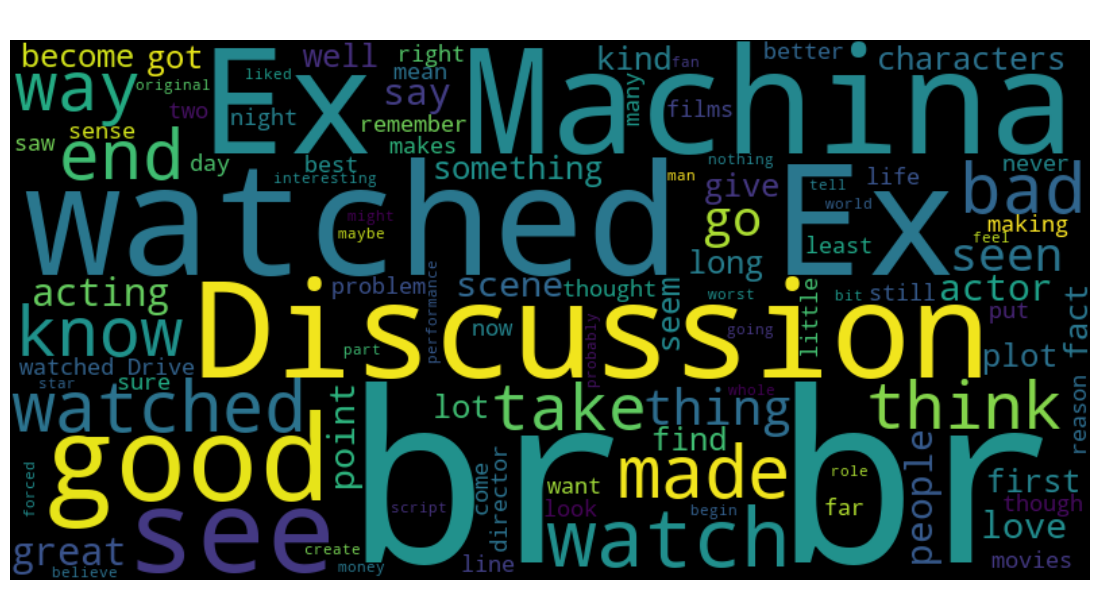

In [29]:
all_text = ' '.join(df['Review_Text'].dropna().values)
generate_cloud(all_text, 'Overall Word Cloud')

### 5.2 Positive Reviews Word Cloud

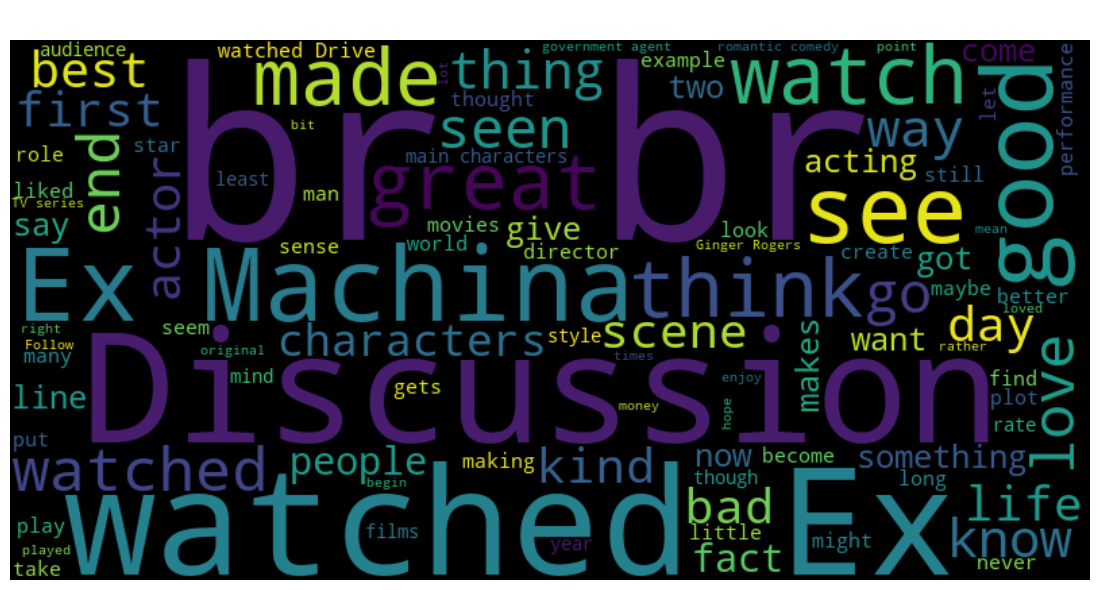

In [30]:
pos_text = ' '.join(df[df['Sentiment'] == 'Positive']['Review_Text'].dropna().values)
generate_cloud(pos_text, 'Positive Reviews Word Cloud')

### 5.3 Negative Reviews Word Cloud

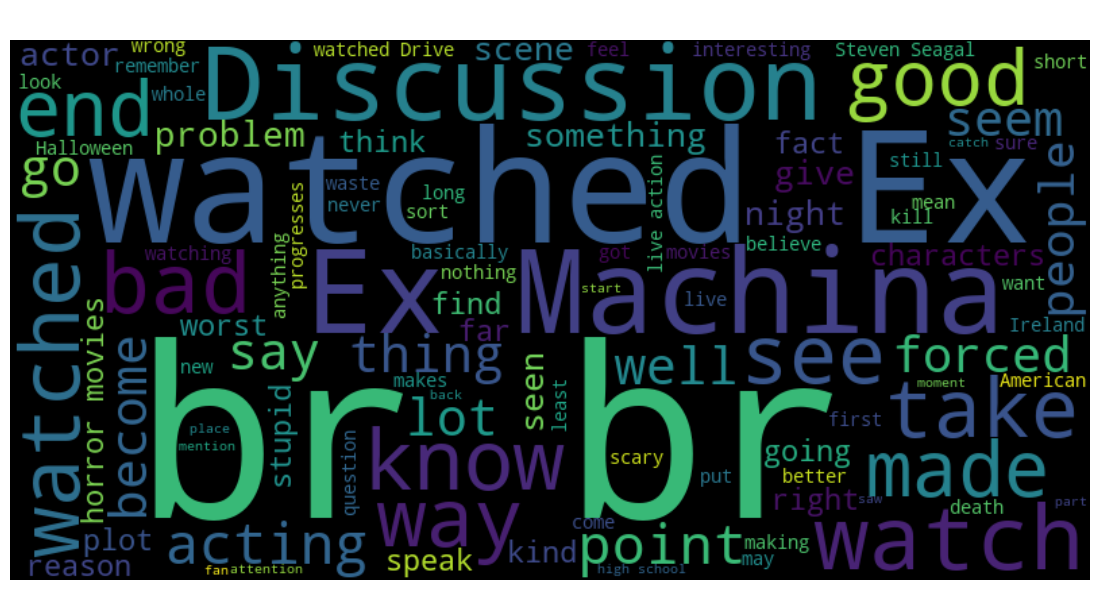

In [31]:
neg_text = ' '.join(df[df['Sentiment'] == 'Negative']['Review_Text'].dropna().values)
generate_cloud(neg_text, 'Negative Reviews Word Cloud')

## 6. Word Embeddings (Word2Vec) & Topic Modeling (LDA)
First we tokenise the text. Then we train a Word2Vec model and LDA models.

### 6.1 Tokenization & Word2Vec Model

In [32]:
w2v_model = Word2Vec(sentences=df['Tokens'], vector_size=100, window=5, min_count=10, workers=4)

# Reduce dimensionality for visualization
words = list(w2v_model.wv.index_to_key)[:150] # Top 150 words
vectors = [w2v_model.wv[w] for w in words]

pca = PCA(n_components=2)
vecs_2d = pca.fit_transform(vectors)

fig_w2v = px.scatter(x=vecs_2d[:,0], y=vecs_2d[:,1], text=words, 
                     title='Word2Vec Embeddings - 2D PCA Projection (Top 150 Words)', 
                     template='plotly_dark', width=900, height=700)
fig_w2v.update_traces(textposition='top center', marker=dict(size=8, color='#00b4d8'))
fig_w2v.show()

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


### 6.2 LDA Topic Modeling

In [33]:
dictionary = corpora.Dictionary(df['Tokens'])
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(text) for text in df['Tokens']]

num_topics = 5
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=10, random_state=42)

print('\n── LDA Topics ──')
for idx, topic in lda_model.print_topics(num_topics=num_topics, num_words=8):
    print(f'Topic {idx+1}: {topic}')


── LDA Topics ──
Topic 1: 0.009*"would" + 0.008*"time" + 0.007*"get" + 0.007*"well" + 0.006*"made" + 0.006*"see" + 0.006*"movie" + 0.005*"ever"
Topic 2: 0.009*"machina" + 0.008*"romantic" + 0.007*"comedy" + 0.007*"follow" + 0.006*"story" + 0.006*"time" + 0.006*"see" + 0.006*"man"
Topic 3: 0.010*"good" + 0.008*"character" + 0.008*"machina" + 0.008*"story" + 0.006*"would" + 0.006*"watch" + 0.005*"thing" + 0.005*"way"
Topic 4: 0.015*"disney" + 0.010*"machina" + 0.009*"well" + 0.008*"something" + 0.008*"best" + 0.008*"show" + 0.007*"would" + 0.007*"plot"
Topic 5: 0.017*"series" + 0.015*"machina" + 0.012*"time" + 0.011*"film" + 0.008*"show" + 0.008*"director" + 0.008*"story" + 0.008*"little"


### 6.3 LDA Topic Distribution Chart

In [34]:
def get_dominant_topic(bow):
    if not bow: return np.nan
    topics = lda_model.get_document_topics(bow)
    dominant = max(topics, key=lambda x: x[1])[0]
    return dominant + 1

df['Dominant_Topic'] = [get_dominant_topic(c) for c in corpus]

topic_counts = df['Dominant_Topic'].value_counts().reset_index()
topic_counts.columns = ['Topic', 'Count']
topic_counts['Topic'] = 'Topic ' + topic_counts['Topic'].astype(int).astype(str)

fig_lda = px.bar(topic_counts, x='Topic', y='Count', color='Topic',
                 title='Dominant Topic Distribution Across Reviews', template='plotly_dark')
fig_lda.show()

## 7. Advanced TF-IDF Information Extraction
Instead of naive Bag-of-Words, we use **Term Frequency-Inverse Document Frequency (TF-IDF)** to isolate the most *informative* terms driving discussion across the entire review corpus. Commonly used but meaningless words are penalized.

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Using the previously cleaned data
texts = df['Cleaned_Review'].dropna().tolist()

vectorizer = TfidfVectorizer(max_features=50, ngram_range=(1, 2))
tfidf_matrix = vectorizer.fit_transform(texts)

# Sum the TF-IDF scores across all documents
word_scores = tfidf_matrix.sum(axis=0).A1
feature_names = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame({'Word': feature_names, 'TF_IDF_Score': word_scores})
tfidf_df = tfidf_df.sort_values(by='TF_IDF_Score', ascending=False).head(20)

fig_tfidf = px.bar(tfidf_df, x='Word', y='TF_IDF_Score', color='TF_IDF_Score', 
                   title='Top 20 Most Highly-Weighted Terms (TF-IDF Penalty Analysis)',
                   template='plotly_dark', color_continuous_scale='Magma')
fig_tfidf.update_layout(xaxis={'categoryorder':'total descending'})
fig_tfidf.show()

## 8. Topic Mining: Word Analysis Graph (Co-Occurrence Network)
Following **Lecture 2 (Text Mining)** methodology, we construct a powerful Social Network of Words. 
Each node represents a prominent word, and each edge thickens based on how frequently the two words appear in the very same review. This creates an intuitive cluster map of reviewer mentality.

In [36]:
import sys
!{sys.executable} -m pip install pyvis

import plotly.graph_objects as go
import networkx as nx
import itertools
import plotly.graph_objects as go

print('Building word co-occurrence matrix...')
# Focus on top nouns from our earlier metrics
top_vocabs = set(tfidf_df['Word'].head(30).tolist())

co_occurrence = {}
for review in df['Tokens'].dropna():
    words = [w for w in review if w in top_vocabs]
    # Generate pairs (combinations)
    for pair in itertools.combinations(set(words), 2):
        pair = tuple(sorted(pair))
        co_occurrence[pair] = co_occurrence.get(pair, 0) + 1

G = nx.Graph()
for (w1, w2), weight in co_occurrence.items():
    if weight > 10: # Only significant connections
        G.add_edge(w1, w2, weight=weight)

# Extract positions
pos = nx.spring_layout(G, k=0.5, seed=42)

edges_x, edges_y = [], []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edges_x.extend([x0, x1, None])
    edges_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edges_x, y=edges_y, line=dict(width=0.5, color='#888'),
    hoverinfo='none', mode='lines')

nodes_x = [pos[node][0] for node in G.nodes()]
nodes_y = [pos[node][1] for node in G.nodes()]

node_degrees = [deg for node, deg in G.degree()]
node_trace = go.Scatter(
    x=nodes_x, y=nodes_y, mode='markers+text', text=list(G.nodes()),
    textposition='top center', hoverinfo='text',
    marker=dict(showscale=True, colorscale='YlGnBu', size=[d*3 for d in node_degrees],
                color=node_degrees, line_width=2))

fig_net = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                title='Word Analysis: Keyword Co-Occurrence Sub-Network',
                title_font_size=16,
                showlegend=False,
                hovermode='closest',
                margin=dict(b=20,l=5,r=5,t=40),
                template='plotly_dark',
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
                )
fig_net.show()

Building word co-occurrence matrix...


## Step 11 — Interactive Sentiment Selection
Use the dropdown below to select any movie and visualize its historical sentiment trend based on the BERT analysis.

In [37]:
# ── INTERACTIVE MOVIE SENTIMENT EXPLORER ──────────────────────────────────────
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Preparation: Aggregate sentiment by Movie and Review_Year
df_viz = pd.read_csv('movie_data_professional.csv')
agg_df = df_viz.groupby(['Movie Title', 'Review_Year']).agg(
    Pos_Rate=('BERT_Sentiment', lambda x: (x == 'Positive').mean()),
    Count=('BERT_Sentiment', 'count')
).reset_index()

# Get unique movies for dropdown
movies = sorted(agg_df['Movie Title'].unique())

# Create base figure
fig = go.Figure()

# Add a trace for each movie (hidden by default except the first one)
for movie in movies:
    m_data = agg_df[agg_df['Movie Title'] == movie]
    fig.add_trace(
        go.Scatter(
            x=m_data['Review_Year'], 
            y=m_data['Pos_Rate'],
            name=movie,
            mode='lines+markers',
            marker=dict(size=10, symbol='diamond'),
            visible=(movie == movies[0]),
            line=dict(width=4, shape='spline'),
            hovertemplate="<b>Year: %{x}</b><br>Positivity: %{y:.1%}<extra></extra>"
        )
    )

# Create buttons for categorical dropdown
buttons = []
for i, movie in enumerate(movies):
    visibility = [False] * len(movies)
    visibility[i] = True
    buttons.append(dict(
        label=movie,
        method="update",
        args=[{"visible": visibility},
              {"title": f"Sentiment Trend for: {movie}"}]
    ))

# Layout with dropdown
fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        direction="down",
        pad={"r": 10, "t": 10},
        showactive=True,
        x=0.0,
        xanchor="left",
        y=1.15,
        yanchor="top",
        bgcolor="#2c3e50",
        font=dict(color="white")
    )],
    title=f"Sentiment Trend for: {movies[0]}",
    xaxis=dict(title="Review Year", gridcolor="#444", dtick=1),
    yaxis=dict(title="Positive Sentiment Rate", tickformat=".0%", gridcolor="#444", range=[0, 1.1]),
    template='plotly_dark',
    height=550,
    margin=dict(t=100)
)

print("Displaying Interactive Explorer...")
fig.show()


Displaying Interactive Explorer...
